# Proyecto 2
## Descripción y Limpieza de Datos

---
## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_columns', 20)
plt.rcParams['figure.figsize'] = (10, 5)

print('Librerías importadas correctamente.')

Librerías importadas correctamente.


---
## 2. Carga de datos

In [2]:
train = pd.read_csv('./data/train.csv')
test  = pd.read_csv('./data/test.csv')
sample_sub = pd.read_csv('./data/sample_submission.csv')

print(f'train : {train.shape[0]:,} filas  ×  {train.shape[1]} columnas')
print(f'test  : {test.shape[0]:,} filas  ×  {test.shape[1]} columnas')
print(f'sample_submission: {sample_sub.shape}')

train : 36,696 filas  ×  7 columnas
test  : 3 filas  ×  5 columnas
sample_submission: (3, 2)


---
## 3. Descripción inicial de las variables

El conjunto de entrenamiento contiene **7 columnas**:

| Variable | Tipo | Descripción |
|---|---|---|
| `row_id` | int | Identificador único de la fila |
| `QuestionId` | int | Identificador de la pregunta de diagnóstico |
| `QuestionText` | str | Texto completo de la pregunta (puede incluir LaTeX e imágenes descritas) |
| `MC_Answer` | str | Respuesta de opción múltiple que seleccionó el estudiante |
| `StudentExplanation` | str | Justificación escrita del estudiante |
| `Category` | str | Etiqueta objetivo (solo en train): combinación de corrección + tipo de error |
| `Misconception` | str | Idea errónea específica identificada (solo en train, NaN cuando no aplica) |

In [3]:
print('TIPOS DE DATOS - TRAIN' )
print(train.dtypes)
print()
train.head(5)

TIPOS DE DATOS - TRAIN
row_id                int64
QuestionId            int64
QuestionText            str
MC_Answer               str
StudentExplanation      str
Category                str
Misconception           str
dtype: object



,row_id,QuestionId,QuestionText,MC_Answer,StudentExplanation,Category,Misconception
0,0,31772,What fraction of the shape is not shaded? Give your answer in its simplest form. [Image: A triangle split into 9 equ...,\( \frac{1}{3} \),0ne third is equal to tree nineth,True_Correct,NaN
1,1,31772,What fraction of the shape is not shaded? Give your answer in its simplest form. [Image: A triangle split into 9 equ...,\( \frac{1}{3} \),1 / 3 because 6 over 9 is 2 thirds and 1 third is not shaded.,True_Correct,NaN
2,2,31772,What fraction of the shape is not shaded? Give your answer in its simplest form. [Image: A triangle split into 9 equ...,\( \frac{1}{3} \),"1 3rd is half of 3 6th, so it is simplee to understand.",True_Neither,NaN
3,3,31772,What fraction of the shape is not shaded? Give your answer in its simplest form. [Image: A triangle split into 9 equ...,\( \frac{1}{3} \),1 goes into everything and 3 goes into nine,True_Neither,NaN
4,4,31772,What fraction of the shape is not shaded? Give your answer in its simplest form. [Image: A triangle split into 9 equ...,\( \frac{1}{3} \),1 out of every 3 isn't coloured,True_Correct,NaN


In [4]:
print('MUESTRA CON MISCONCEPTION')
train[train['Misconception'].notna()][['QuestionText','MC_Answer','StudentExplanation','Category','Misconception']].head(4)

MUESTRA CON MISCONCEPTION


,QuestionText,MC_Answer,StudentExplanation,Category,Misconception
107,What fraction of the shape is not shaded? Give your answer in its simplest form. [Image: A triangle split into 9 equ...,\( \frac{1}{3} \),3 out of 9 parts aren't shaded.,True_Misconception,Incomplete
120,What fraction of the shape is not shaded? Give your answer in its simplest form. [Image: A triangle split into 9 equ...,\( \frac{1}{3} \),3 out of 9 triangles are not shaded.,True_Misconception,Incomplete
123,What fraction of the shape is not shaded? Give your answer in its simplest form. [Image: A triangle split into 9 equ...,\( \frac{1}{3} \),3 out of nine triangles are not shaded,True_Misconception,Incomplete
265,What fraction of the shape is not shaded? Give your answer in its simplest form. [Image: A triangle split into 9 equ...,\( \frac{1}{3} \),3/9 of the shape isn't shaded,True_Misconception,Incomplete


---
## 4. Análisis de valores nulos

La columna `Misconception` contiene valores nulos por diseño: solo registra un error cuando la categoría incluye la palabra *Misconception*. El resto de columnas no deberían tener nulos.

In [5]:
null_counts = train.isnull().sum()
null_pct    = (null_counts / len(train) * 100).round(2)

null_df = pd.DataFrame({'Nulos': null_counts, 'Porcentaje (%)': null_pct})
print(null_df)

# Verificar que Misconception es NA únicamente cuando Category no contiene 'Misconception'
print()
print('Verificación de consistencia Category ↔ Misconception:')
for cat in train['Category'].unique():
    sub    = train[train['Category'] == cat]
    na_cnt = sub['Misconception'].isna().sum()
    print(f'  {cat:<25s}: {len(sub):5d} filas | NaN en Misconception: {na_cnt:5d} ({na_cnt/len(sub)*100:.1f}%)')

                    Nulos  Porcentaje (%)
row_id                  0            0.00
QuestionId              0            0.00
QuestionText            0            0.00
MC_Answer               0            0.00
StudentExplanation      0            0.00
Category                0            0.00
Misconception       26836           73.13

Verificación de consistencia Category ↔ Misconception:
  True_Correct             : 14802 filas | NaN en Misconception: 14802 (100.0%)
  True_Neither             :  5265 filas | NaN en Misconception:  5265 (100.0%)
  True_Misconception       :   403 filas | NaN en Misconception:     0 (0.0%)
  False_Neither            :  6542 filas | NaN en Misconception:  6542 (100.0%)
  False_Misconception      :  9457 filas | NaN en Misconception:     0 (0.0%)
  False_Correct            :   227 filas | NaN en Misconception:   227 (100.0%)


**Hallazgo:** La columna `Misconception` es `NaN` en las categorías donde no hay idea errónea (`True_Correct`, `True_Neither`, `False_Neither`, `False_Correct`). Esta ausencia de valores es estructuralmente correcta y no requiere imputación.

---
## 5. Distribución de categorías

                     Frecuencia  Porcentaje (%)
Category                                       
True_Correct              14802           40.34
False_Misconception        9457           25.77
False_Neither              6542           17.83
True_Neither               5265           14.35
True_Misconception          403            1.10
False_Correct               227            0.62


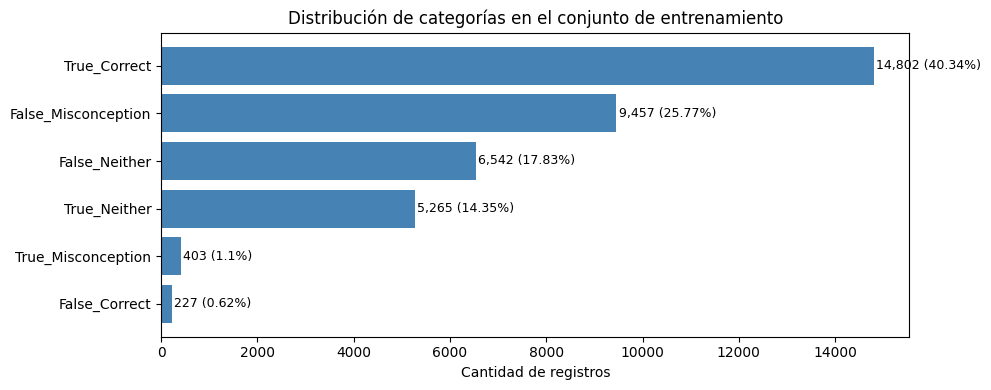

In [7]:
cat_counts = train['Category'].value_counts()
cat_pct    = train['Category'].value_counts(normalize=True).mul(100).round(2)

cat_df = pd.DataFrame({'Frecuencia': cat_counts, 'Porcentaje (%)': cat_pct})
print(cat_df)

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(cat_counts.index, cat_counts.values, color='steelblue')
for i, (v, p) in enumerate(zip(cat_counts.values, cat_pct.values)):
    ax.text(v + 50, i, f'{v:,} ({p}%)', va='center', fontsize=9)
ax.set_xlabel('Cantidad de registros')
ax.set_title('Distribución de categorías en el conjunto de entrenamiento')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Observación: la clase dominante es True_Correct (40.3%), mientras que True_Misconception y False_Correct son clases muy minoritarias (<1.5%).

---
## 6. Preguntas de diagnóstico únicas

In [8]:
n_questions = train['QuestionId'].nunique()
print(f'Número de preguntas de diagnóstico únicas: {n_questions}')
print(f'Promedio de respuestas por pregunta: {len(train)/n_questions:.1f}')
print()
print('Respuestas por pregunta:')
print(train.groupby('QuestionId').size().sort_values(ascending=False).rename('n_respuestas').to_frame())

print()
print('Preguntas únicas y su texto:')
for qid, row in train.drop_duplicates('QuestionId').set_index('QuestionId')['QuestionText'].items():
    print(f'  [{qid}] {row[:100]}...' if len(row) > 100 else f'  [{qid}] {row}')

Número de preguntas de diagnóstico únicas: 15
Promedio de respuestas por pregunta: 2446.4

Respuestas por pregunta:
            n_respuestas
QuestionId              
31772               4857
31778               3640
31774               3115
32833               3105
89443               3054
31777               2809
33472               2800
91695               2610
32835               2332
32829               2156
33474               1766
33471               1542
76870               1186
109465              1051
104665               673

Preguntas únicas y su texto:
  [31772] What fraction of the shape is not shaded? Give your answer in its simplest form. [Image: A triangle ...
  [31774] Calculate \( \frac{1}{2} \div 6 \)
  [31777] A box contains \( 120 \) counters. The counters are red or blue. \( \frac{3}{5} \) of the counters a...
  [31778] \( \frac{A}{10}=\frac{9}{15} \) What is the value of \( A \) ?
  [32829] \( 2 y=24 \) What is the value of \( y \) ?
  [32833] Calculate \( \frac{

---
## 7. Análisis de las ideas erróneas (Misconception)

In [9]:
misc_series = train['Misconception'].dropna()
print(f'Registros con Misconception: {len(misc_series):,}')
print(f'Ideas erróneas únicas (raw): {misc_series.nunique()}')
print()
print('Tabla de frecuencia de ideas erróneas:')
misc_counts = misc_series.value_counts()
print(misc_counts.to_frame())

Registros con Misconception: 9,860
Ideas erróneas únicas (raw): 35

Tabla de frecuencia de ideas erróneas:
                                        count
Misconception                                
Incomplete                               1454
Additive                                  929
Duplication                               704
Subtraction                               620
Positive                                  566
Wrong_term                                558
Irrelevant                                497
Wrong_fraction                            418
Inversion                                 414
Mult                                      353
Denominator-only_change                   336
Whole_numbers_larger                      329
Adding_across                             307
WNB                                       299
Tacking                                   290
Unknowable                                282
Wrong_Fraction                            273
SwapDividend       

### Problema detectado: inconsistencia de capitalización

Se detectaron dos versiones del mismo error: `Wrong_fraction` (418 casos) y `Wrong_Fraction` (273 casos). Son la misma categoría con diferente capitalización, lo que genera una etiqueta duplicada.

In [10]:
print('Variantes de Wrong_fraction:')
print(train['Misconception'].value_counts()[['Wrong_fraction','Wrong_Fraction']])

Variantes de Wrong_fraction:
Misconception
Wrong_fraction    418
Wrong_Fraction    273
Name: count, dtype: int64


---
## 8. Análisis de longitud de textos

In [11]:
train['len_QuestionText']      = train['QuestionText'].str.len()
train['len_StudentExplanation'] = train['StudentExplanation'].str.len()
train['len_MC_Answer']         = train['MC_Answer'].str.len()

print('Estadísticas de longitud de texto (caracteres):')
print(train[['len_QuestionText','len_StudentExplanation','len_MC_Answer']].describe().round(1))

Estadísticas de longitud de texto (caracteres):
       len_QuestionText  len_StudentExplanation  len_MC_Answer
count           36696.0                 36696.0        36696.0
mean               97.3                    70.0           12.9
std                66.2                    38.7            6.6
min                29.0                     1.0            6.0
25%                36.0                    43.0            8.0
50%                62.0                    60.0            9.0
75%               160.0                    86.0           18.0
max               226.0                   586.0           36.0


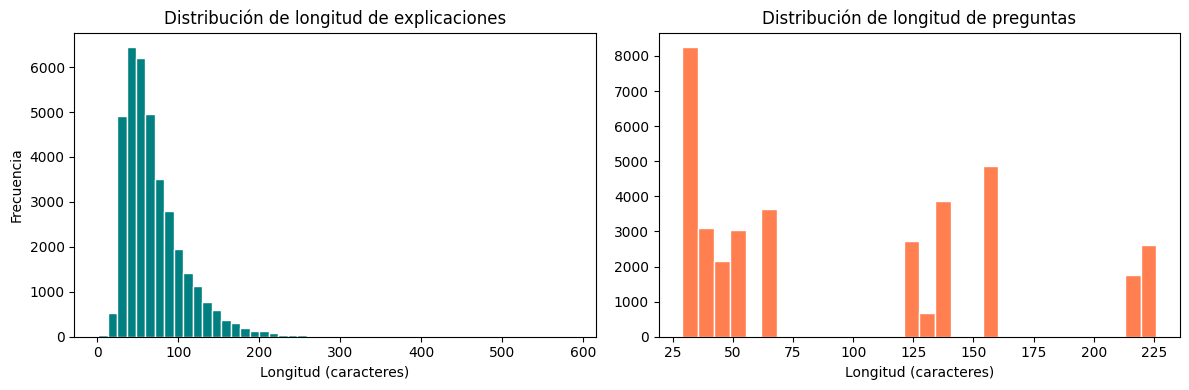

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train['len_StudentExplanation'], bins=50, color='teal', edgecolor='white')
axes[0].set_xlabel('Longitud (caracteres)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de longitud de explicaciones')

axes[1].hist(train['len_QuestionText'], bins=30, color='coral', edgecolor='white')
axes[1].set_xlabel('Longitud (caracteres)')
axes[1].set_title('Distribución de longitud de preguntas')

plt.tight_layout()
plt.show()

### Problema detectado: explicaciones muy cortas

In [13]:
very_short = train[train['len_StudentExplanation'] <= 5]
print(f'Explicaciones de 5 o menos caracteres: {len(very_short)}')
print()
print(very_short[['row_id','StudentExplanation','Category']].to_string())

Explicaciones de 5 o menos caracteres: 12

       row_id StudentExplanation       Category
2349     2349              1 / 2  False_Neither
2960     2960                3/9  False_Neither
2961     2961                3/9  False_Neither
19162   19162               (B).  False_Neither
29315   29315                -13  False_Neither
29316   29316                -13  False_Neither
29317   29317                -13  False_Neither
29403   29403                 ??  False_Neither
30133   30133                 -3   True_Neither
30752   30752                  d   True_Neither
30776   30776                 d.   True_Neither
35669   35669                 b.  False_Neither


---
## 9. Detección de duplicados en explicaciones

In [14]:
dup_explanations = train[train.duplicated(subset=['QuestionId','MC_Answer','StudentExplanation'], keep=False)]
print(f'Filas con combinación (QuestionId + MC_Answer + StudentExplanation) duplicada: {len(dup_explanations)}')

# Ver un ejemplo
ejemplo_dup = dup_explanations.groupby(['QuestionId','MC_Answer','StudentExplanation']).filter(lambda x: len(x) > 1).head(6)
print()
print('Ejemplo de explicaciones duplicadas:')
ejemplo_dup[['row_id','QuestionId','MC_Answer','StudentExplanation','Category']].head(6)

Filas con combinación (QuestionId + MC_Answer + StudentExplanation) duplicada: 1377

Ejemplo de explicaciones duplicadas:


,row_id,QuestionId,MC_Answer,StudentExplanation,Category
14,14,31772,\( \frac{1}{3} \),1/3 is equal to 3 because if 3 are not shared in so 3/6 in its simplest form is 1/3.,True_Neither
15,15,31772,\( \frac{1}{3} \),1/3 is equal to 3 because if 3 are not shared in so 3/6 in its simplest form is 1/3.,True_Neither
26,26,31772,\( \frac{1}{3} \),1/3 is the same as 3/9.,True_Correct
27,27,31772,\( \frac{1}{3} \),1/3 is the same as 3/9.,True_Correct
28,28,31772,\( \frac{1}{3} \),1/3 is the same as 3/9.,True_Correct
29,29,31772,\( \frac{1}{3} \),1/3 is the simplest form of 3/9,True_Correct


---
## 10. Limpieza de datos

Con base en el análisis anterior se realizan las siguientes operaciones de limpieza:

| # | Operación | Justificación |
|---|---|---|
| 1 | Unificar capitalización de `Wrong_Fraction` → `Wrong_fraction` | Etiquetas duplicadas por error de capitalización |
| 2 | Rellenar `Misconception` NaN con `'NA'` (string) | Facilita el manejo posterior sin perder información estructural |
| 3 | Eliminar espacios en blanco al inicio/fin de textos | Asegurar consistencia en las columnas de texto |
| 4 | Marcar explicaciones muy cortas (≤5 chars) | No se eliminan (pueden ser válidas en algunos contextos), pero se registra la bandera |
| 5 | Eliminar columnas auxiliares de longitud | Eran para diagnóstico, no deben quedar en el df limpio |

In [15]:
train_clean = train.copy()

# 1. Unificar capitalización de Misconception
train_clean['Misconception'] = train_clean['Misconception'].replace('Wrong_Fraction', 'Wrong_fraction')

print('Verificación (Wrong_Fraction debe desaparecer):')
print(train_clean['Misconception'].value_counts()[['Wrong_fraction']].to_frame())
assert 'Wrong_Fraction' not in train_clean['Misconception'].values, 'Aún existe Wrong_Fraction'

Verificación (Wrong_Fraction debe desaparecer):
                count
Misconception        
Wrong_fraction    691


In [16]:
# 2. Rellenar NaN en Misconception con 'NA'
train_clean['Misconception'] = train_clean['Misconception'].fillna('NA')

print('Nulos en Misconception después del relleno:', train_clean['Misconception'].isna().sum())

Nulos en Misconception después del relleno: 0


In [17]:
# 3. Strip de espacios en columnas de texto
text_cols = ['QuestionText', 'MC_Answer', 'StudentExplanation', 'Category', 'Misconception']
for col in text_cols:
    train_clean[col] = train_clean[col].str.strip()

print('Strip aplicado a columnas:', text_cols)

Strip aplicado a columnas: ['QuestionText', 'MC_Answer', 'StudentExplanation', 'Category', 'Misconception']


In [18]:
# 4. Bandera de explicaciones muy cortas
train_clean['short_explanation'] = train_clean['StudentExplanation'].str.len() <= 5

print(f'Filas con explicación muy corta (flag=True): {train_clean["short_explanation"].sum()}')

Filas con explicación muy corta (flag=True): 12


In [19]:
# 5. Eliminar columnas auxiliares de diagnóstico
cols_to_drop = ['len_QuestionText', 'len_StudentExplanation', 'len_MC_Answer']
train_clean = train_clean.drop(columns=cols_to_drop, errors='ignore')

print('Columnas finales del dataframe limpio:')
print(train_clean.columns.tolist())

print('\nShape final:', train_clean.shape)

Columnas finales del dataframe limpio:
['row_id', 'QuestionId', 'QuestionText', 'MC_Answer', 'StudentExplanation', 'Category', 'Misconception', 'short_explanation']

Shape final: (36696, 8)


---
## 11. Resumen del dataset limpio

In [20]:
print('RESUMEN')
print(f' - Filas totales         : {len(train_clean):,}')
print(f' - Columnas              : {train_clean.shape[1]}')
print(f' - Preguntas únicas      : {train_clean["QuestionId"].nunique()}')
print(f' - Categorías únicas     : {train_clean["Category"].nunique()}')
print(f' - Ideas erróneas únicas : {train_clean["Misconception"].nunique() - 1} (+ "NA")')
print(f' - Filas sin nulos       : {train_clean.notnull().all(axis=1).sum():,}')

print('\nNulos por columna:')
print(train_clean.isnull().sum())

RESUMEN
 - Filas totales         : 36,696
 - Columnas              : 8
 - Preguntas únicas      : 15
 - Categorías únicas     : 6
 - Ideas erróneas únicas : 34 (+ "NA")
 - Filas sin nulos       : 36,696

Nulos por columna:
row_id                0
QuestionId            0
QuestionText          0
MC_Answer             0
StudentExplanation    0
Category              0
Misconception         0
short_explanation     0
dtype: int64


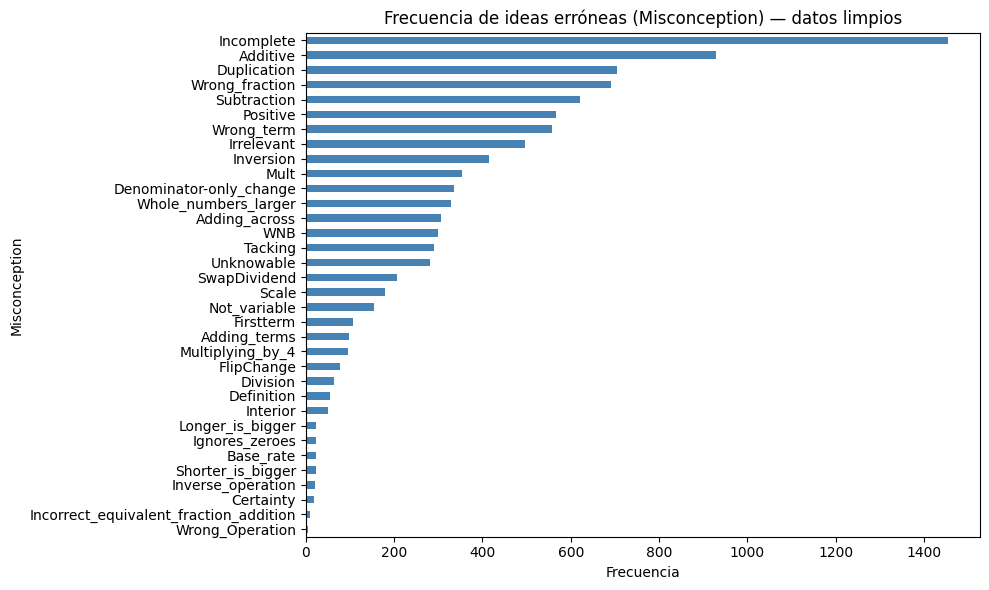

In [21]:
# Distribución final de Misconception (excluyendo NA)
misc_clean = train_clean[train_clean['Misconception'] != 'NA']['Misconception'].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
misc_clean.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Frecuencia')
ax.set_title('Frecuencia de ideas erróneas (Misconception) — datos limpios')
plt.tight_layout()
plt.show()

In [22]:
# Guardar datos limpios
train_clean.to_csv('./data/train_clean.csv', index=False)
print('Archivo train_clean.csv guardado.')

Archivo train_clean.csv guardado.


---
## 12. Conclusiones de la limpieza

1. **Nulos estructurales:** La columna `Misconception` tiene ~73% de valores nulos, pero esto es correcto por diseño: solo existe una idea errónea cuando la categoría la contiene. Se reemplazaron los NaN por `'NA'` (string) para facilitar el manejo en etapas posteriores.

2. **Inconsistencia de etiquetas:** Se unificó `Wrong_Fraction` y `Wrong_fraction` en una sola etiqueta (`Wrong_fraction`), reduciendo el número de ideas erróneas únicas de 35 a 34.

3. **Explicaciones muy cortas:** Se identificaron 12 filas con explicaciones de 5 o menos caracteres. Todas pertenecen a categorías sin ideas erróneas (`False_Neither`, `True_Neither`), por lo que **no se eliminan** pero quedan marcadas con la bandera `short_explanation`.

4. **Sin filas duplicadas exactas:** No se encontraron filas completamente duplicadas. Sí existen explicaciones textuales repetidas entre distintos estudiantes, lo cual es esperado en este contexto.

5. **Calidad general:** El dataset está en buenas condiciones para el análisis exploratorio. La mayor área de trabajo posterior será el procesamiento de texto (LaTeX en preguntas y respuestas, variabilidad ortográfica en explicaciones de estudiantes).